In [24]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns
import os 
sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
dataset_dict_nivo = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
responderCrit = original_data['BR'].isin(['CR','PR'])
progressorCrit = original_data['BR'].isin(['PD'])

responders = original_data[responderCrit].index
progressors = original_data[progressorCrit].index

original_data.loc[responders,"Labels"] = 'Responder'
original_data.loc[progressors,"Labels"] = 'Progressor'

dataset_dict["Origin"] = original_data


seed = 3
os.makedirs(f"CRPR_PD/Seed_{seed}", exist_ok = True)
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}", f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
    responderCrit = syn_df['BR'].isin(['CR','PR'])
    progressorCrit = syn_df['BR'].isin(['PD'])
    
    responders = syn_df[responderCrit].index
    progressors = syn_df[progressorCrit].index
    
    syn_df.loc[responders,"Labels"] = 'Responder'
    syn_df.loc[progressors,"Labels"] = 'Progressor'
    dataset_dict[tool] = syn_df


genes_cols = original_data.iloc[:,54:-1].columns.tolist()
        
symbols_dataset_dict = {}

for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    # genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    # drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    # genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    # genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t

### **ssGSEA**

In [25]:
ssGSEA = {}
for k, df in symbols_dataset_dict.items():
    ss = gp.ssgsea(data=df,
                   gene_sets="h.all.v2025.1.Hs.symbols.gmt",
                   sample_norm_method='log_rank', # choose 'custom' will only use the raw value of `data`
                   no_plot=False)
    ssdf = ss.res2d.to_csv(f'CRPR_PD/Seed_{seed}/ssGSEA_{k}.csv')
    ssGSEA[k] = ss.res2d

### **Differential Analysis**

## **Jaccard Index**

In [26]:
from ssGSEA import ssGSEA_differential
dataset_metadata = {}
for name, data in dataset_dict.items():
    # data = data[data['Arm'] == 'NIVOLUMAB']
    # data = data[data['Benefit']!='ICB']
    
    metadata = pd.DataFrame(
        {"Patient": data.index.tolist(),
         "Labels": data['Labels'].values.tolist()
        }
    )
    dataset_metadata[name]=metadata
phenotypes =  {"Labels": ["Responder","Progressor"]}

DifferentialAnalysis_ssGSEA = ssGSEA_differential(
    ssGSEA,
    dataset_metadata,
    phenotypes,
    id_col = "Patient",
    term_col = "Term",
    sample_col = "Name",
    nes_col = "NES",
    alpha = 0.05)

for name, DEA_ssGSEA in DifferentialAnalysis_ssGSEA.items():
    DEA_ssGSEA.to_csv(f'CRPR_PD/Seed_{seed}/DEA_ssGSEA_{name}.csv')

### **Spearman Correlations**

In [27]:
from Utils import compute_jaccard_indices, extract_significances

orig_paths = extract_significances(DifferentialAnalysis_ssGSEA["Origin"], term_col="Term", adj_p_col="P_value", threshold=0.05)
synth_paths_dict = {k: extract_significances(v, term_col="Term", adj_p_col="P_value", threshold=0.05)
                     for k, v in DifferentialAnalysis_ssGSEA.items() if k != "Origin"}

jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
jaccard_df.to_csv(f'CRPR_PD/Seed_{seed}/JaccardIndex_{seed}.csv')
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_3,6,0,0,6,0.000000
1,avatarsk10_3,6,1,1,6,0.166667
2,ctgan_3,6,3,1,8,0.125000
3,gaussiancopula_3,6,6,2,10,0.200000
4,synthpop_3,6,0,0,6,0.000000
5,tvae_3,6,41,6,41,0.146341


In [28]:
from Utils import spearman_across_datasets

# DifferentialAnalysis_ssGSEA_Sig = {}
# for data, ssGSEA in DifferentialAnalysis_ssGSEA.items():
#     ssGSEA_sig = ssGSEA[ssGSEA['Term'].isin(orig_paths)]
#     DifferentialAnalysis_ssGSEA_Sig[data]=ssGSEA_sig

spearman_df,_ = spearman_across_datasets(
    gsea_overall=DifferentialAnalysis_ssGSEA,
    origin="Origin",
    term_col="Term",
    score_col="Diff_NES",
    min_terms=3,
)


spearman_df.to_csv(f'CRPR_PD/Seed_{seed}/Spearman_{seed}.csv')
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_3,0.328307,1.992828e-02,50
1,avatarsk5_3,0.615654,1.950549e-06,50
2,ctgan_3,0.144778,3.157938e-01,50
3,gaussiancopula_3,0.622185,1.410628e-06,50
4,synthpop_3,0.429916,1.833500e-03,50
5,tvae_3,0.635726,7.032393e-07,50


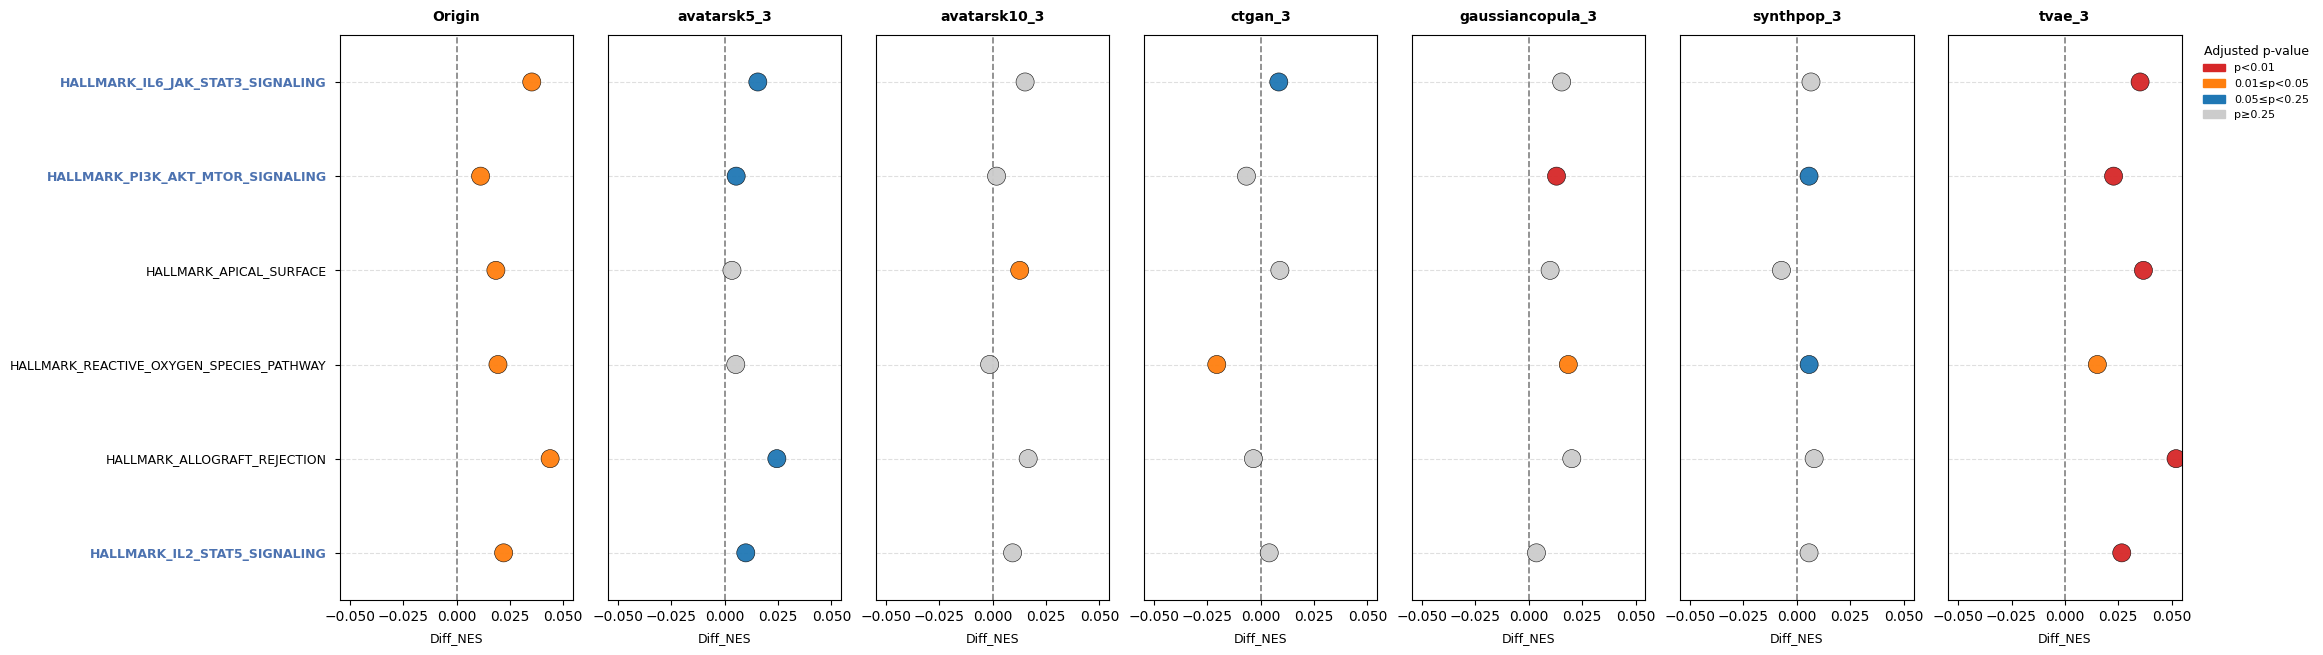

In [29]:
from ssGSEA import plot_pathway

ref_pathway_list = orig_paths
highlight_pathways = ['HALLMARK_IL6_JAK_STAT3_SIGNALING','HALLMARK_PI3K_AKT_MTOR_SIGNALING','HALLMARK_IL2_STAT5_SIGNALING']

# Call the plotting function
fig, df_used = plot_pathway(
    ssGSEA_comparison=DifferentialAnalysis_ssGSEA,
    ref_pathway_list=ref_pathway_list, 
    highlight_pathways=highlight_pathways,
    origin_name = "Origin",
    term_col = "Term",
    pval_col = "P_value",
    diff_col = "Diff_NES",
    show=True,
    save_path=f'CRPR_PD/Seed_{seed}/BubblePlot_ssGSEA.png'
)